100%|██████████| 1.89M/1.89M [00:00<00:00, 131MB/s]

Extracting files...
Dataset Path: /root/.cache/kagglehub/datasets/swatikhedekar/exploratory-data-analysis-on-netflix-data/versions/11
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  Septem

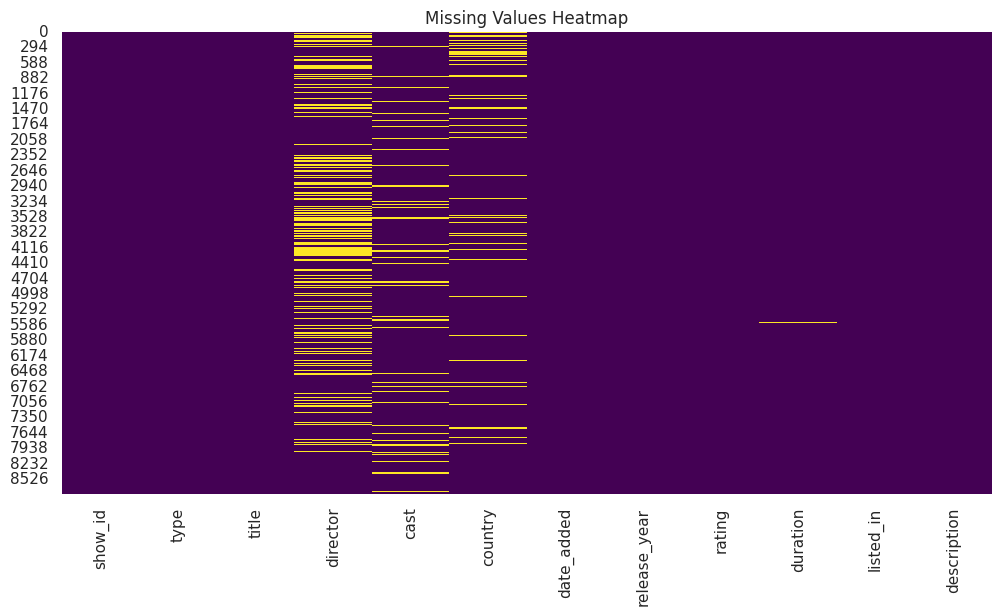


Duplicate Rows: 0
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   

              country       date_added rating  duration  \
count            7976             8797   8803      8804   
unique            748             1767     17       220   
top     United States  January 1, 2020  TV-MA  1 Season   
freq             2818              109   3207      1793   

                           listed_in  \
count                           8807   
unique                           514   
top     Dramas, International Movies   
freq

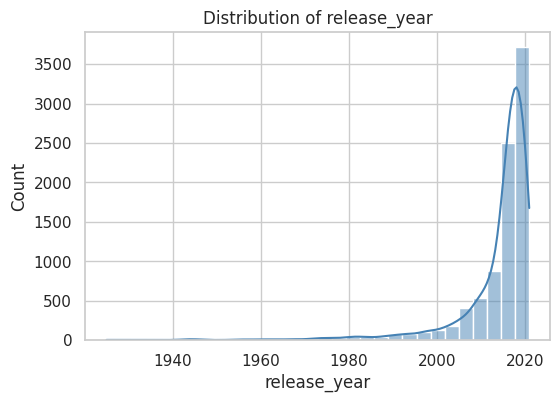

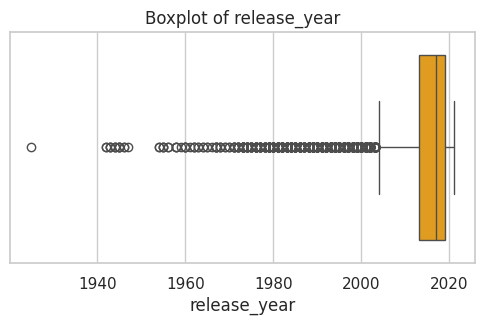

/tmp/ipykernel_5542/4217850823.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


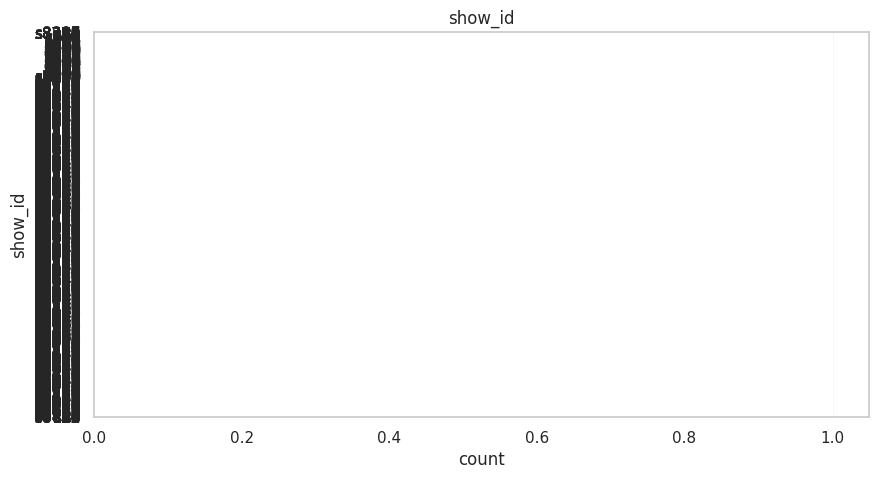

/tmp/ipykernel_5542/4217850823.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


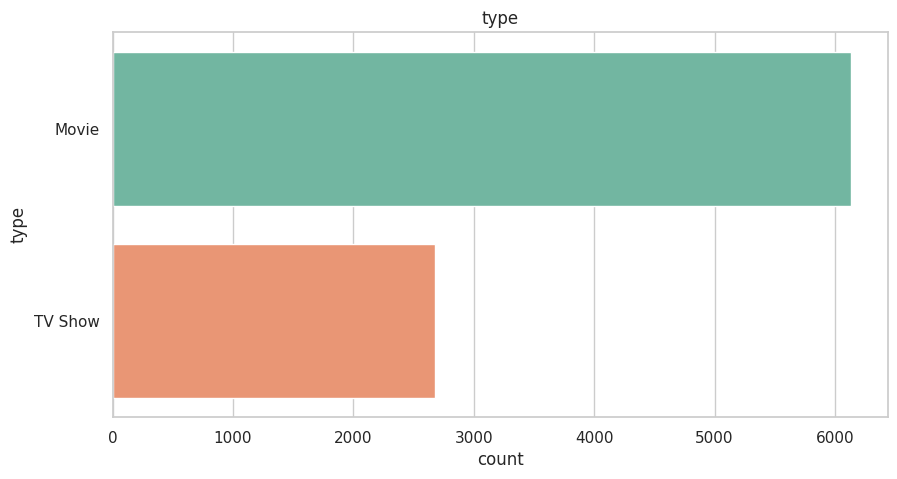

/tmp/ipykernel_5542/4217850823.py:156: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28023 (\N{CJK UNIFIED IDEOGRAPH-6D77}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20799 (\N{CJK UNIFIED IDEOGRAPH-513F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from 

In [ ]:
# Import Required Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Display all columns
pd.set_option("display.max_columns", None)

# Set Seaborn style
sns.set(style="whitegrid")

# Download Dataset
path = kagglehub.dataset_download(
    "swatikhedekar/exploratory-data-analysis-on-netflix-data"
)

print("Dataset Path:", path)

# Find CSV file automatically
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]

if len(csv_files) == 0:
    raise FileNotFoundError("No CSV file found in the downloaded dataset.")

df = pd.read_csv(os.path.join(path, csv_files[0]))

# Basic Exploration
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

print("\nData Types:")
print(df.dtypes)


# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

missing = (df.isnull().sum() / len(df)) * 100
print("\nMissing Percentage:")
print(missing.sort_values(ascending=False))

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Duplicate Records
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

# Statistical Summary
print(df.describe())

print(df.describe(include="object"))

# Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

print("\nNumerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

# Distribution of Numerical Features
for col in numerical_cols:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        color="steelblue"
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Boxplots (Outlier Detection)
for col in numerical_cols:
    plt.figure(figsize=(6, 3))

    sns.boxplot(
        x=df[col],
        color="orange"
    )

    plt.title(f"Boxplot of {col}")
    plt.show()

# Correlation Matrix
if len(numerical_cols) > 1:

    plt.figure(figsize=(8, 6))

    corr = df[numerical_cols].corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="coolwarm",
        fmt=".2f"
    )

    plt.title("Correlation Matrix")
    plt.show()


# Pair Plot

if len(numerical_cols) > 1:
    sns.pairplot(df[numerical_cols[:5]])
    plt.show()


# Count Plots

for col in categorical_cols:
    plt.figure(figsize=(10, 5))

    sns.countplot(
        data=df,
        y=col,
        order=df[col].value_counts().index,
        palette="Set2"
    )

    plt.title(f"{col}")
    plt.show()

# Top 10 Categories

for col in categorical_cols:

    top = df[col].value_counts().head(10)

    plt.figure(figsize=(8, 4))

    sns.barplot(
        x=top.values,
        y=top.index,
        palette="Set2"
    )

    plt.title(f"Top 10 {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()


# Unique Values
print("\nUnique Values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

# Skewness

print("\nSkewness:")
print(df[numerical_cols].skew())

# Outlier Count using IQR
print("\nOutlier Count (IQR Method):")

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)
    upper = Q3 + (1.5 * IQR)

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")